In [59]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as ex

In [60]:
df=pd.read_csv(r"5. ARIMAX and SARIMAX models\Climate.csv")

In [61]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [62]:
df.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [63]:
for i in range(0,len(df['date']),50):
    print(df['date'][i:i+50])

0     2013-01-01
1     2013-01-02
2     2013-01-03
3     2013-01-04
4     2013-01-05
5     2013-01-06
6     2013-01-07
7     2013-01-08
8     2013-01-09
9     2013-01-10
10    2013-01-11
11    2013-01-12
12    2013-01-13
13    2013-01-14
14    2013-01-15
15    2013-01-16
16    2013-01-17
17    2013-01-18
18    2013-01-19
19    2013-01-20
20    2013-01-21
21    2013-01-22
22    2013-01-23
23    2013-01-24
24    2013-01-25
25    2013-01-26
26    2013-01-27
27    2013-01-28
28    2013-01-29
29    2013-01-30
30    2013-01-31
31    2013-02-01
32    2013-02-02
33    2013-02-03
34    2013-02-04
35    2013-02-05
36    2013-02-06
37    2013-02-07
38    2013-02-08
39    2013-02-09
40    2013-02-10
41    2013-02-11
42    2013-02-12
43    2013-02-13
44    2013-02-14
45    2013-02-15
46    2013-02-16
47    2013-02-17
48    2013-02-18
49    2013-02-19
Name: date, dtype: object
50    2013-02-20
51    2013-02-21
52    2013-02-22
53    2013-02-23
54    2013-02-24
55    2013-02-25
56    2013-02-26
57   

In [64]:
df['date']=pd.to_datetime(df['date'],format="%Y-%m-%d")

In [65]:
df=df.sort_values(by='date')
df=df.set_index('date')

In [66]:
df.head()

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000


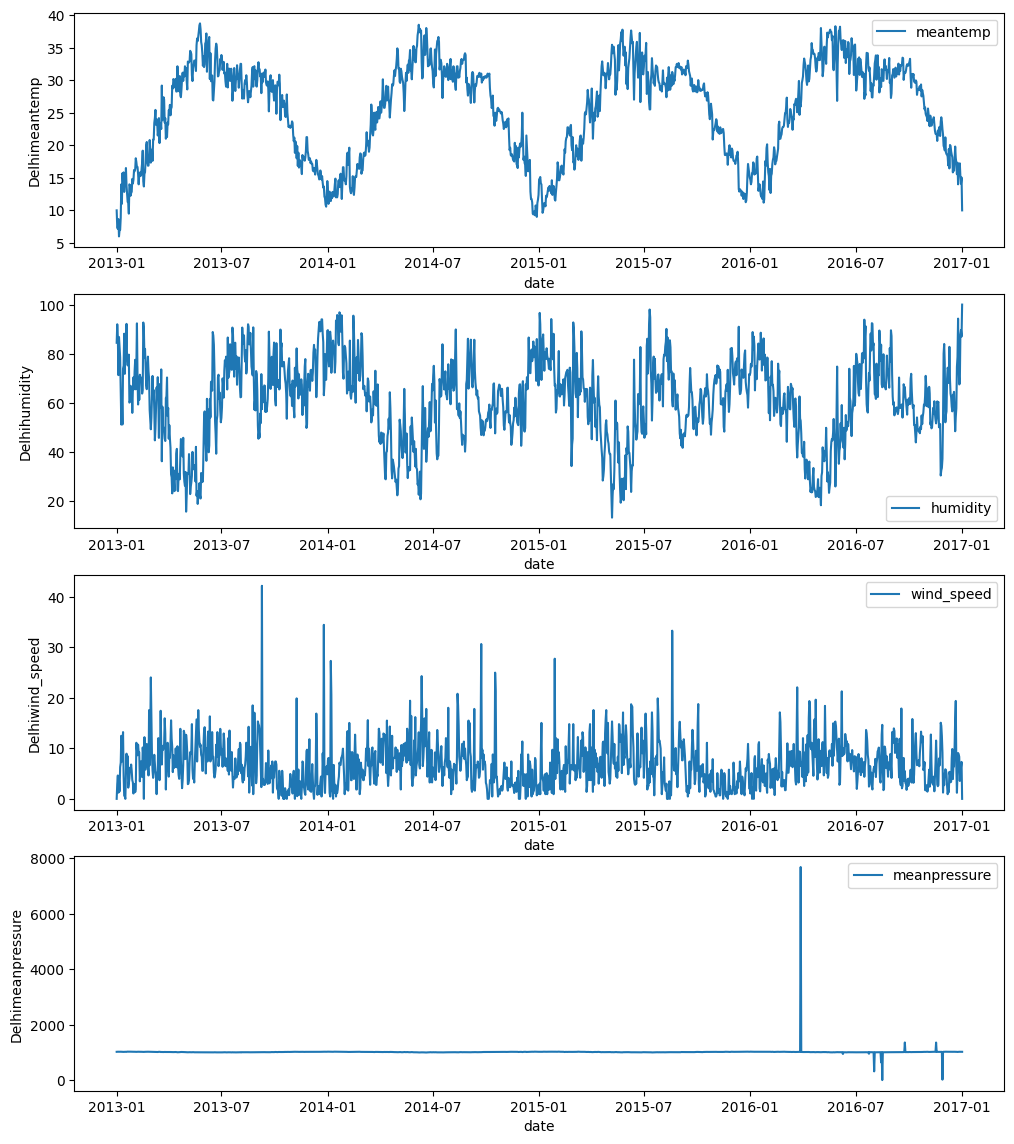

In [67]:
plt.figure(figsize=(12,14))
for i in range(len(df.columns)):
    plt.subplot(4,1,i+1)
    sns.lineplot(x=df.index,y=df.iloc[:,i],label=df.columns[i])
    if isinstance(df.columns[i],str):
        plt.ylabel('Delhi'+df.columns[i])
plt.legend()
plt.show()


decompose

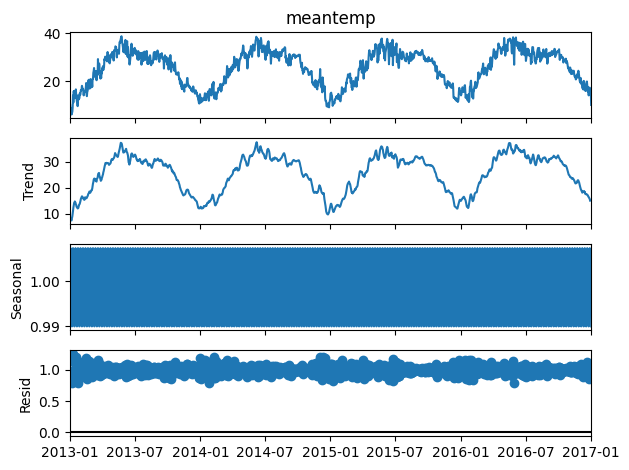

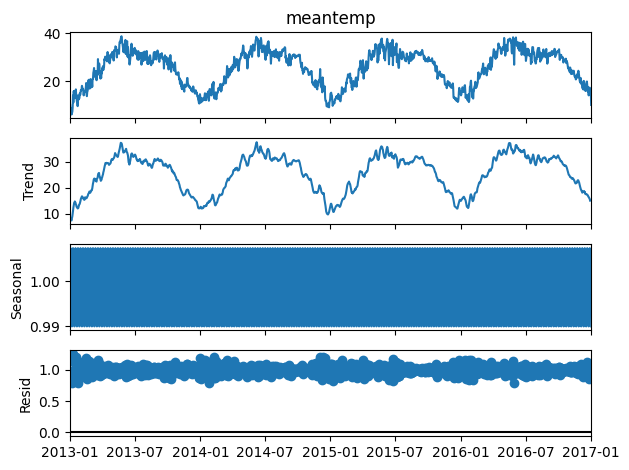

In [68]:
import statsmodels.api as sm
decomp = sm.tsa.seasonal_decompose(df['meantemp'],model='multiplicative')
decomp.plot()

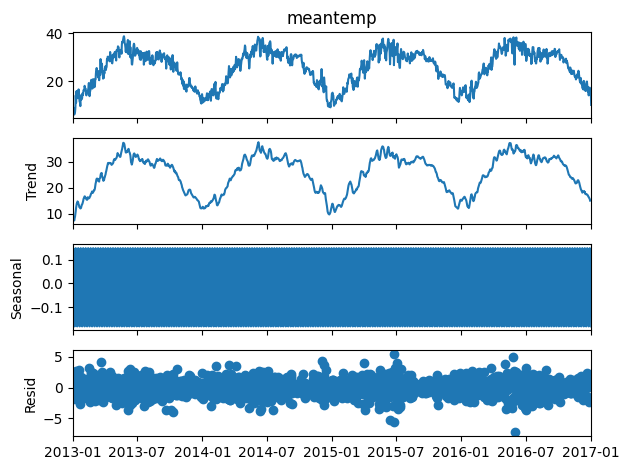

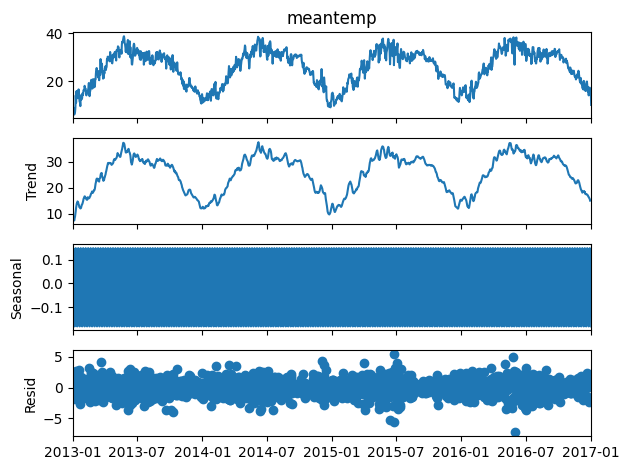

In [69]:
decomp2 = sm.tsa.seasonal_decompose(df['meantemp'],model='additive')
decomp2.plot()

create train and test sets

In [70]:
len_train=np.ceil(df.shape[0]*.75).astype(int)
train=df['meantemp'][:len_train]
test=df['meantemp'][len_train:]

holts-winters exponential smoothing

In [71]:
df.iloc[::365,:]

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2014-01-01,13.375000,89.625000,7.650000,1021.000000
2015-01-01,14.750000,72.000000,0.925000,1017.500000
2016-01-01,14.714286,72.285714,1.057143,1021.142857
2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [72]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
sl=0.047
ss=0
model = ExponentialSmoothing(train,seasonal_periods=352,trend='multiplicative',seasonal='additive')
model_fit = model.fit(smoothing_level=sl,smoothing_slope=ss)
#print(model_fit.params)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\user\AppData\Local\Temp\ipykernel_15760\314889323.py:5: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  model_fit = model.fit(smoothing_level=sl,smoothing_slope=ss)


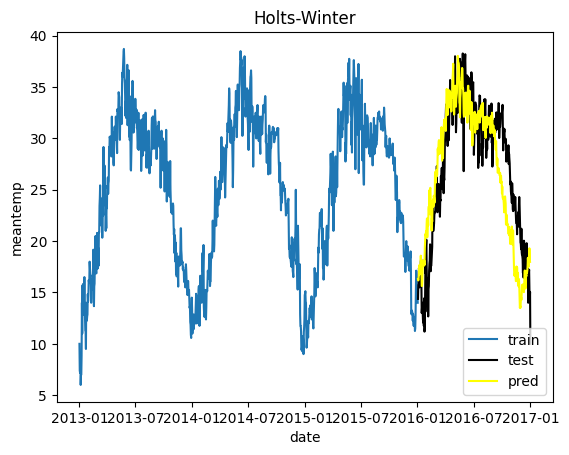

In [73]:
df['hw_pred']=model_fit.forecast(364)
hw_pred=df['hw_pred']
title='Holts-Winter'
def plot(train,test,df,len_train,pred,title):
    sns.lineplot(x=df.index[:len_train],y=train,label='train')
    sns.lineplot(x=df.index[len_train:],y=test,label='test',color='black')
    sns.lineplot(x=df.index,y=pred,label='pred',color='yellow')
    plt.title(title)
    plt.legend()
    plt.show()
plot(train,test,df,len_train,hw_pred,title)

In [74]:
def get_score_metrics(true, y_pred):
    y_true = true.copy()
    
    # Handle different input types
    if isinstance(y_true, pd.DataFrame):
        y_true = y_true.iloc[:, 0]  # Take first column if DataFrame
    elif isinstance(y_true, pd.Series):
        y_true = y_true.values  # Convert Series to numpy array
    # If it's already a numpy array, leave as is
    
    metrics = {'metric': [], 'score': []}
    
    # Rest of your function remains the same
    mfe = np.mean(y_true - y_pred).round(3)
    metrics['metric'].append('MFE')
    metrics['score'].append(mfe)

    
    mae = np.mean(np.abs(y_true - y_pred)).round(3)
    metrics['metric'].append('MAE')
    metrics['score'].append(mae)
    
    mape = (np.mean(np.abs((y_true - y_pred) / y_true)) * 100).round(3)
    metrics['metric'].append('MAPE')
    metrics['score'].append(mape)

    mse = np.mean((y_true - y_pred)**2).round(3)
    metrics['metric'].append('MSE')
    metrics['score'].append(mse)

    rmse = np.sqrt(mse).round(3)
    metrics['metric'].append('RMSE')
    metrics['score'].append(rmse)

    metric_df=pd.DataFrame(metrics)
    return metric_df


In [75]:
get_score_metrics(test, hw_pred[len_train:])

,metric,score
0,MFE,0.446
1,MAE,3.342
2,MAPE,13.954
3,MSE,16.418
4,RMSE,4.052


Auto correlated models

In [76]:
from statsmodels.tsa.stattools import kpss
res=kpss(df['meantemp'])
print(f'test stat -> p_value -> num_lags -> critical values')
print(res)
print([res[1]>0.05]+[f'@{k}:{res[0]<v}' for k,v in res[3].items()])

test stat -> p_value -> num_lags -> critical values
(0.18786352260533618, 0.1, 25, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})
[True, '@10%:True', '@5%:True', '@2.5%:True', '@1%:True']


C:\Users\user\AppData\Local\Temp\ipykernel_15760\1363787290.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res=kpss(df['meantemp'])


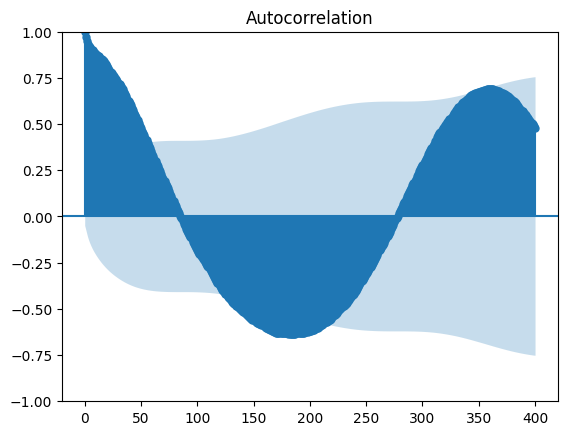

In [77]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df['meantemp'],lags=400)
plt.show()

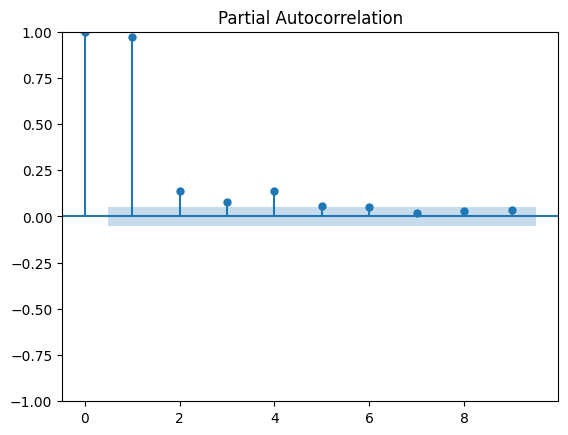

In [78]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df['meantemp'],lags=9)
plt.show()

new splits for exog

In [79]:
tr_len=int(np.ceil(df.shape[0]*.75))
tr=df.iloc[:tr_len,:]
te=df.iloc[tr_len:,:]

arimax

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(tr['meantemp'],order=(365,1,7),exog=tr['humidity'])
model_fit=model.fit()
print(model_fit.params)

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\user\AppD

In [ ]:
df['armax_predict']=model_fit.predict(te['meantemp'].index.min(),te['meantemp'].index.max(),exog=te['humidity'])                                                                

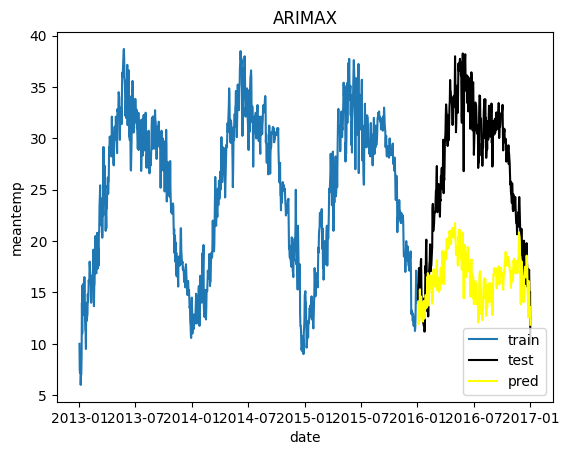

In [ ]:
plot(tr['meantemp'],te['meantemp'],df,len_train,df['armax_predict'],'ARIMAX')

In [ ]:
get_score_metrics(te, df['armax_predict'])

,metric,score
0,MFE,10.474
1,MAE,10.562
2,MAPE,35.429
3,MSE,145.901
4,RMSE,12.079


In [ ]:
import joblib
from joblib import dump, load
joblib.dump(model,'arimax.pkl')

['arimax.pkl']

sarimax

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarimax_model = SARIMAX(tr['meantemp'],order=(8,1,4),
            seasonal_order=(365,0,1,4),exog=tr['humidity'])
sarimax_model_fit = sarimax_model.fit()

ValueError: Invalid model: autoregressive lag(s) {4} are in both the seasonal and non-seasonal autoregressive components.

In [ ]:
df['sarimax_predict']=sarimax_model_fit.predict(te.index.min(),te.index.max(),exog=df['humidity'][tr_len:])

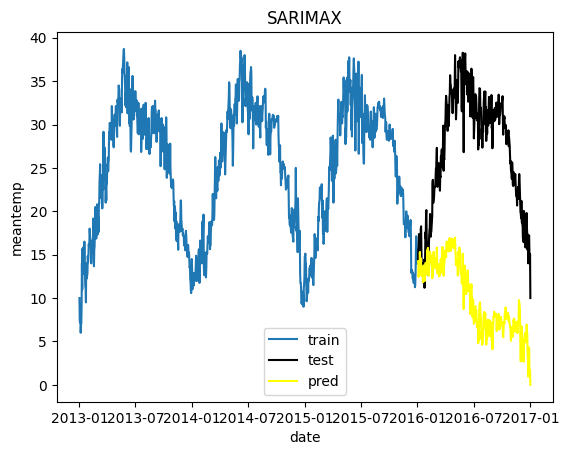

In [ ]:
plot(tr['meantemp'],te['meantemp'],df,len_train,df['sarimax_predict'],'SARIMAX')

In [ ]:
get_score_metrics(te, df['sarimax_predict'])

,metric,score
0,MFE,16.998
1,MAE,17.036
2,MAPE,60.042
3,MSE,344.948
4,RMSE,18.573


In [ ]:
import joblib
from joblib import dump, load
joblib.dump(sarimax_model,'sarimax.pkl')

['sarimax.pkl']